# Contour Maps of Hurricane Maria on a 15–3 km MPAS Mesh

Author: [Dylan Nelson](https://github.com/dylannelson)

This example draws contour maps from a regional MPAS-A simulation of September 2017, a few hours
before Hurricane Maria made landfall in Puerto Rico:

1. Sea-level pressure contours over 10 m wind speed around the storm.
2. 500 hPa geopotential height contours over precipitable water across the region.

## Imports

In [1]:
import warnings

import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

import uxarray as ux

warnings.filterwarnings("ignore", message=r".*(No spatial coordinate|np\.dot\(\))")

## Data

The simulation is described in *Regional Multi-Week Convection-Permitting Simulations using the
Model for Prediction Across Scales (MPAS-A) for use in the Caribbean, Mexico, and Central America
Regions* (Núñez Ocasio, Bacmeister, Xue and Morrison; NSF NCAR GDEX dataset
[d010077](https://gdex.ucar.edu/datasets/d010077/),
[doi:10.5065/PNB8-GD97](https://doi.org/10.5065/PNB8-GD97))

In [2]:
grid_path = "/gdex/data/d010077/native_diag/MAAG.static.nc"
data_path = "/gdex/data/d010077/native_diag/diag.2017-09-20_06.00.00.nc"

uxds = ux.open_dataset(grid_path, data_path)

## Preparing the Fields

Computing and tranforming the variables we want to use

In [3]:
mslp = uxds["mslp"].isel(Time=0) / 100  # sea-level pressure, Pa converted to hPa
u10 = uxds["u10"].isel(Time=0)  # 10 m wind, eastward component (m/s)
v10 = uxds["v10"].isel(Time=0)  # 10 m wind, northward component (m/s)
wind = (u10**2 + v10**2) ** 0.5  # 10 m wind speed (m/s)
z500 = uxds["height_500hPa"].isel(Time=0)  # height of the 500 hPa pressure surface (m)
pw = uxds["precipw"].isel(Time=0)  # precipitable water (kg/m², the same as mm)

## Map 1: Pressure over Wind Speed

### Selecting the Storm

{meth}`~uxarray.UxDataArray.subset.bounding_box` keeps only the cells in a latitude–longitude box around the
storm. Reducing the data size by subsetting will speed up the following computation steps.

In [4]:
storm_box = dict(lon_bounds=(-71, -59), lat_bounds=(13, 22))

mslp_storm = mslp.subset.bounding_box(**storm_box)
wind_storm = wind.subset.bounding_box(**storm_box)
print(
    f"{mslp.uxgrid.n_face:,} cells in the mesh, {mslp_storm.uxgrid.n_face:,} around the storm"
)

6,087,575 cells in the mesh, 152,236 around the storm


### Shading with `to_raster`

{meth}`~uxarray.UxDataArray.to_raster` samples the mesh at every pixel of the map, and
`imshow` draws the result. With `return_pixel_mapping=True` it also returns which cell each pixel
fell in, so a later map with the same size and extent can skip the sampling step. See
[Plotting with Matplotlib and Cartopy](../../user-guide/mpl.ipynb) for more on this method.

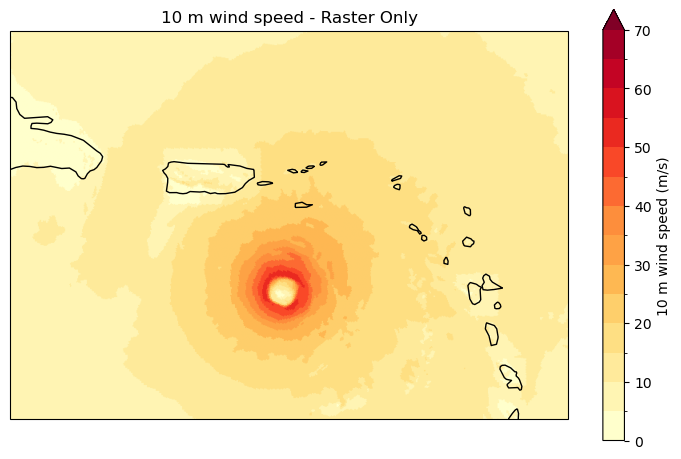

In [5]:
extent = [-70, -60, 14, 21]
wind_levels = np.arange(0, 71, 5)
wind_norm = mcolors.BoundaryNorm(wind_levels, 256, extend="max")

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(extent)
raster, pixel_mapping = wind_storm.to_raster(ax=ax, return_pixel_mapping=True)
img = ax.imshow(
    raster,
    origin="lower",
    extent=ax.get_xlim() + ax.get_ylim(),
    cmap="YlOrRd",
    norm=wind_norm,
)
ax.coastlines("50m")
fig.colorbar(img, ax=ax, shrink=0.8, label="10 m wind speed (m/s)")
ax.set_title("10 m wind speed - Raster Only")
plt.show()

### Contour Lines with `remap.bilinear`

A regular grid is built with {meth}`~uxarray.Grid.from_structured`, and the pressure is remapped
onto it with {meth}`~uxarray.UxDataArray.remap.bilinear`. The remapped values come back in rows
of constant latitude, so they reshape to a 2-D (latitude, longitude) array that Matplotlib's
`contour` accepts.

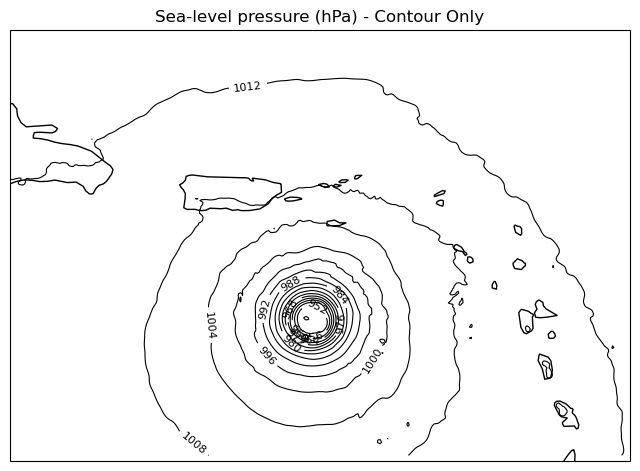

In [6]:
def to_latlon_grid(uxda, lon, lat):
    """Bilinearly remap face-centered data onto a regular lon/lat grid, as a 2-D array."""
    target = ux.Grid.from_structured(lon=lon, lat=lat)
    remapped = uxda.remap.bilinear(destination_grid=target)
    return remapped.values.reshape(len(lat), len(lon))


lon = np.arange(-70, -60, 0.03)
lat = np.arange(14, 21, 0.03)
mslp_grid = to_latlon_grid(mslp_storm, lon, lat)

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(extent)
contours = ax.contour(
    lon, lat, mslp_grid, levels=np.arange(900, 1016, 4), colors="k", linewidths=0.8
)
ax.clabel(contours, fontsize=8)
ax.coastlines("50m")
ax.set_title("Sea-level pressure (hPa) - Contour Only")
plt.show()

Bilinear remapping interpolates between cell centers, so the lines are smooth. Contouring the
`to_raster` image instead also works, but the lines step along cell edges because each pixel
takes the value of the cell it falls in.

### Combining the Two

The same two steps on one map: wind speed shading, then pressure contours on top, labeled every
8 hPa. The map has the same size and extent as the first one, so `to_raster` reuses its pixel
mapping.

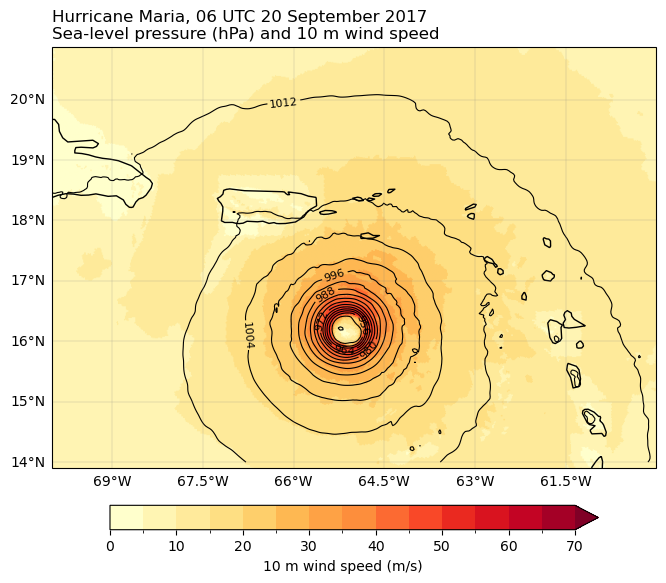

In [7]:
fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(extent)

raster = wind_storm.to_raster(ax=ax, pixel_mapping=pixel_mapping)
img = ax.imshow(
    raster,
    origin="lower",
    extent=ax.get_xlim() + ax.get_ylim(),
    cmap="YlOrRd",
    norm=wind_norm,
)

contours = ax.contour(
    lon, lat, mslp_grid, levels=np.arange(900, 1016, 4), colors="k", linewidths=0.8
)
ax.clabel(contours, levels=contours.levels[::2], fontsize=8)

ax.coastlines("50m")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = gl.right_labels = False
fig.colorbar(
    img,
    ax=ax,
    orientation="horizontal",
    shrink=0.7,
    pad=0.07,
    label="10 m wind speed (m/s)",
)
ax.set_title(
    "Hurricane Maria, 06 UTC 20 September 2017\nSea-level pressure (hPa) and 10 m wind speed",
    loc="left",
)
plt.show()

## Map 2: 500 hPa Height over Precipitable Water

The same approach at a larger scale, covering most of the simulation domain. The contour grid is
coarser (0.25°) to match the larger area. The subset box is a little larger than the map because
Cartopy stretches the map to fit the figure.

In [8]:
region_box = dict(lon_bounds=(-105, -35), lat_bounds=(0, 48))
z500_region = z500.subset.bounding_box(**region_box)
pw_region = pw.subset.bounding_box(**region_box)

lon_r = np.arange(-100, -40, 0.25)
lat_r = np.arange(5, 40, 0.25)
z500_grid = to_latlon_grid(z500_region, lon_r, lat_r)

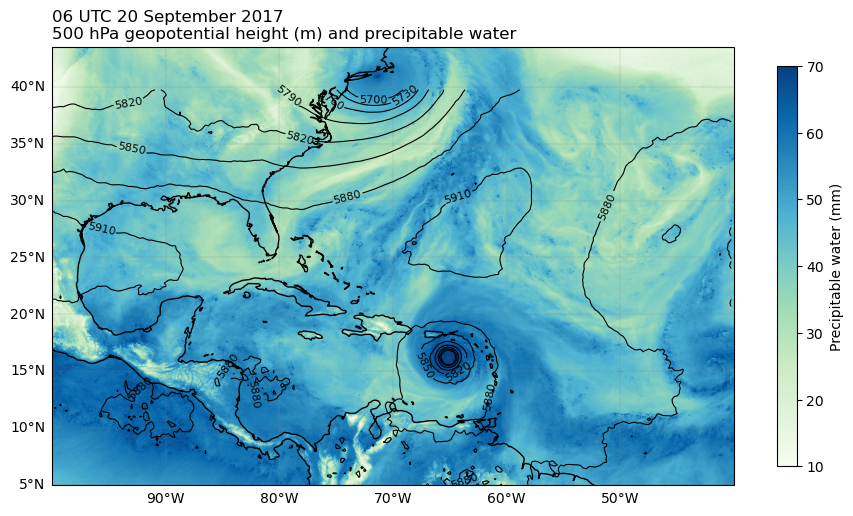

In [9]:
fig, ax = plt.subplots(figsize=(11, 6.5), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-100, -40, 5, 40])

raster = pw_region.to_raster(ax=ax)
img = ax.imshow(
    raster,
    origin="lower",
    extent=ax.get_xlim() + ax.get_ylim(),
    cmap="GnBu",
    vmin=10,
    vmax=70,
)

contours = ax.contour(
    lon_r,
    lat_r,
    z500_grid,
    levels=np.arange(5700, 5950, 30),
    colors="k",
    linewidths=0.8,
)
ax.clabel(contours, fmt="%d", fontsize=8)

ax.coastlines("50m")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = gl.right_labels = False
fig.colorbar(img, ax=ax, shrink=0.8, label="Precipitable water (mm)")
ax.set_title(
    "06 UTC 20 September 2017\n500 hPa geopotential height (m) and precipitable water",
    loc="left",
)
plt.show()